## Relaxed Challenge

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
users_df = pd.read_csv('takehome_users.csv', encoding='latin-1')
engagement_df = pd.read_csv('takehome_user_engagement.csv', encoding='latin-1')

In [4]:
print("=" * 80)
print("USER TABLE OVERVIEW")
print("=" * 80)
print(f"\nColumns: {users_df.columns.tolist()}")
print(f"\nShape: {users_df.shape}")
print(f"\nData Types:\n{users_df.dtypes}")
print(f"\nFirst few rows:")
print(users_df.head())
print(f"\nMissing values:\n{users_df.isnull().sum()}")

print("\n" + "=" * 80)
print("ENGAGEMENT TABLE OVERVIEW")
print("=" * 80)
print(f"\nColumns: {engagement_df.columns.tolist()}")
print(f"\nShape: {engagement_df.shape}")
print(f"\nData Types:\n{engagement_df.dtypes}")
print(f"\nFirst few rows:")
print(engagement_df.head(10))
print(f"\nMissing values:\n{engagement_df.isnull().sum()}")
print(f"\nUnique users in engagement data: {engagement_df.iloc[:, 0].nunique()}")

USER TABLE OVERVIEW

Columns: ['object_id', 'creation_time', 'name', 'email', 'creation_source', 'last_session_creation_time', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip', 'org_id', 'invited_by_user_id']

Shape: (12000, 10)

Data Types:
object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
dtype: object

First few rows:
   object_id        creation_time               name  \
0          1  2014-04-22 03:53:30     Clausen August   
1          2  2013-11-15 03:45:04      Poole Matthew   
2          3  2013-03-19 23:14:52  Bottrill Mitchell   
3          4  2013-05-21 08:09:28    Clausen Nicklas   
4          5  2013-01-17 10:14:20          Raw Grace   

  

## 2. Define Adopted Users

An "adopted user" is defined as a user who has logged in on **three separate days within at least one seven-day period**.

I will:
1. Parse the engagement data dates
2. Group logins by user and find if any 7-day window contains 3+ login days
3. Create an adoption flag for each user

In [5]:
# Parse dates
engagement_df['time_stamp'] = pd.to_datetime(engagement_df['time_stamp'])
users_df['creation_time'] = pd.to_datetime(users_df['creation_time'])
users_df['last_session_creation_time'] = pd.to_datetime(users_df['last_session_creation_time'], unit='s')

In [6]:

def identify_adopted_users(engagement_data):
    """
    Identify adopted users: those with 3+ login days in any 7-day window
    """
    adopted_users = set()
    
    for user_id, group in engagement_data.groupby('user_id'):
        # Get unique dates for this user
        login_dates = sorted(group['time_stamp'].dt.date.unique())
        
        # Check all possible 7-day windows
        for i, start_date in enumerate(login_dates):
            # Find all logins within 7 days of start_date
            window_end = start_date + timedelta(days=6)  # 7-day period inclusive
            logins_in_window = [d for d in login_dates if start_date <= d <= window_end]
            
            # If we have 3+ distinct days in this window, mark as adopted
            if len(logins_in_window) >= 3:
                adopted_users.add(user_id)
                break  # User is adopted, no need to check further windows
    
    return adopted_users

In [8]:
# Identify adopted users
adopted_users = identify_adopted_users(engagement_df)
# Add adoption flag to users dataframe
users_df['is_adopted'] = users_df['object_id'].isin(adopted_users)

In [9]:
print("=" * 80)
print("ADOPTION ANALYSIS")
print("=" * 80)
print(f"\nTotal users: {len(users_df)}")
print(f"Adopted users: {users_df['is_adopted'].sum()}")
print(f"Non-adopted users: {(~users_df['is_adopted']).sum()}")
print(f"Adoption rate: {users_df['is_adopted'].sum() / len(users_df) * 100:.2f}%")

# Verify adoption definition
print("\nAdoption breakdown:")
print(users_df['is_adopted'].value_counts())
print("\nAdoption rate by count:")
print(users_df['is_adopted'].value_counts(normalize=True))

ADOPTION ANALYSIS

Total users: 12000
Adopted users: 1602
Non-adopted users: 10398
Adoption rate: 13.35%

Adoption breakdown:
is_adopted
False    10398
True      1602
Name: count, dtype: int64

Adoption rate by count:
is_adopted
False    0.8665
True     0.1335
Name: proportion, dtype: float64


## 3. Extract User Features

Engineer features from the user table that may predict adoption:
- **creation_source**: How the account was created (5 categories)
- **account_age at first_login**: Days between account creation and first login
- **opted_in_to_mailing_list**: Whether user opted into marketing emails
- **enabled_for_marketing_drip**: Whether user is on marketing drip
- **has_org_id**: Whether user belongs to an organization
- **invited_by_user_id**: Whether user was invited by another user
- **login_activity**: Total login days and days since last login

In [10]:
# Calculate login statistics per user
login_stats = engagement_df.groupby('user_id').agg({
    'time_stamp': ['min', 'max', 'count']
}).reset_index()
login_stats.columns = ['user_id', 'first_login', 'last_login', 'total_login_records']

# Count unique login days per user
unique_login_days = engagement_df.groupby('user_id')['time_stamp'].apply(
    lambda x: (x.dt.date.nunique())
).reset_index()
unique_login_days.columns = ['user_id', 'unique_login_days']

# Merge with login stats
login_stats = login_stats.merge(unique_login_days, on='user_id', how='left')

# Calculate days since last login (relative to max date in data)
max_date = engagement_df['time_stamp'].max()
login_stats['days_since_last_login'] = (max_date - pd.to_datetime(login_stats['last_login'])).dt.days

# Merge with users dataframe
features_df = users_df.copy()
features_df = features_df.merge(login_stats, left_on='object_id', right_on='user_id', how='left')

# Fill NaN for users with no login activity
features_df['first_login'] = features_df['first_login'].fillna(features_df['creation_time'])
features_df['unique_login_days'] = features_df['unique_login_days'].fillna(0)
features_df['days_since_last_login'] = features_df['days_since_last_login'].fillna(
    (max_date - features_df['creation_time']).dt.days
)

# Calculate account age at first login
features_df['account_age_at_first_login'] = (
    pd.to_datetime(features_df['first_login']) - features_df['creation_time']
).dt.days

# Create binary features
features_df['has_org_id'] = features_df['org_id'].notna().astype(int)
features_df['was_invited'] = features_df['invited_by_user_id'].notna().astype(int)
features_df['opted_in_mailing'] = features_df['opted_in_to_mailing_list'].astype(int)
features_df['enabled_marketing_drip'] = features_df['enabled_for_marketing_drip'].astype(int)

In [11]:
print("=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)
print(f"\nFeatures created:")
print(f"  - creation_source: {features_df['creation_source'].nunique()} categories")
print(f"  - account_age_at_first_login: avg {features_df['account_age_at_first_login'].mean():.1f} days")
print(f"  - unique_login_days: avg {features_df['unique_login_days'].mean():.1f} days")
print(f"  - days_since_last_login: avg {features_df['days_since_last_login'].mean():.1f} days")
print(f"  - has_org_id: {features_df['has_org_id'].sum()} users ({features_df['has_org_id'].mean()*100:.1f}%)")
print(f"  - was_invited: {features_df['was_invited'].sum()} users ({features_df['was_invited'].mean()*100:.1f}%)")
print(f"  - opted_in_mailing: {features_df['opted_in_mailing'].sum()} users ({features_df['opted_in_mailing'].mean()*100:.1f}%)")
print(f"  - enabled_marketing_drip: {features_df['enabled_marketing_drip'].sum()} users ({features_df['enabled_marketing_drip'].mean()*100:.1f}%)")

print("\nCreation source distribution:")
print(features_df['creation_source'].value_counts())
print("\nData types after engineering:")
print(features_df[['creation_source', 'account_age_at_first_login', 'unique_login_days', 
                    'has_org_id', 'was_invited', 'opted_in_mailing', 'enabled_marketing_drip', 'is_adopted']].dtypes)

FEATURE ENGINEERING

Features created:
  - creation_source: 5 categories
  - account_age_at_first_login: avg 0.7 days
  - unique_login_days: avg 17.3 days
  - days_since_last_login: avg 281.0 days
  - has_org_id: 12000 users (100.0%)
  - was_invited: 6417 users (53.5%)
  - opted_in_mailing: 2994 users (24.9%)
  - enabled_marketing_drip: 1792 users (14.9%)

Creation source distribution:
creation_source
ORG_INVITE            4254
GUEST_INVITE          2163
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
Name: count, dtype: int64

Data types after engineering:
creation_source                object
account_age_at_first_login      int64
unique_login_days             float64
has_org_id                      int64
was_invited                     int64
opted_in_mailing                int64
enabled_marketing_drip          int64
is_adopted                       bool
dtype: object


## 4. Analyze Adoption Predictors

Perform statistical analysis to identify which factors are predictive of adoption:
- Cross-tabulations for categorical features
- Distributions for continuous features
- Chi-square tests for categorical associations
- T-tests for continuous variables

In [14]:
# 1. CREATION SOURCE
print("\n1. CREATION SOURCE vs ADOPTION")
print("-" * 50)
ct_source = pd.crosstab(features_df['creation_source'], features_df['is_adopted'], margins=True)
print(ct_source)

# Add adoption rate
adoption_by_source = features_df.groupby('creation_source')['is_adopted'].agg(['sum', 'count'])
adoption_by_source['adoption_rate'] = (adoption_by_source['sum'] / adoption_by_source['count']) * 100
print("\nAdoption rate by creation source:")
print(adoption_by_source.sort_values('adoption_rate', ascending=False))

# Chi-square test
chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['creation_source'], features_df['is_adopted']))[0:2]
print(f"\nChi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")


1. CREATION SOURCE vs ADOPTION
--------------------------------------------------
is_adopted          False  True    All
creation_source                       
GUEST_INVITE         1803   360   2163
ORG_INVITE           3701   553   4254
PERSONAL_PROJECTS    1947   164   2111
SIGNUP               1794   293   2087
SIGNUP_GOOGLE_AUTH   1153   232   1385
All                 10398  1602  12000

Adoption rate by creation source:
                    sum  count  adoption_rate
creation_source                              
SIGNUP_GOOGLE_AUTH  232   1385      16.750903
GUEST_INVITE        360   2163      16.643551
SIGNUP              293   2087      14.039291
ORG_INVITE          553   4254      12.999530
PERSONAL_PROJECTS   164   2111       7.768830

Chi-square test: χ² = 92.28, p-value = 0.0000


In [15]:
# 2. MAILING LIST OPT-IN
print("\n2. MAILING LIST OPT-IN vs ADOPTION")
print("-" * 50)
ct_mailing = pd.crosstab(features_df['opted_in_mailing'], features_df['is_adopted'], margins=True)
print(ct_mailing)

adoption_by_mailing = features_df.groupby('opted_in_mailing')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_mailing['adoption_rate'] = adoption_by_mailing['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_mailing)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['opted_in_mailing'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")


2. MAILING LIST OPT-IN vs ADOPTION
--------------------------------------------------
is_adopted        False  True    All
opted_in_mailing                    
0                  7818  1188   9006
1                  2580   414   2994
All               10398  1602  12000

Adoption breakdown:
                   sum  count      mean  adoption_rate
opted_in_mailing                                      
0                 1188   9006  0.131912      13.191206
1                  414   2994  0.138277      13.827655
Chi-square test: χ² = 0.73, p-value = 0.3920


In [16]:
# 3. MARKETING DRIP
print("\n3. MARKETING DRIP ENABLED vs ADOPTION")
print("-" * 50)
ct_drip = pd.crosstab(features_df['enabled_marketing_drip'], features_df['is_adopted'], margins=True)
print(ct_drip)

adoption_by_drip = features_df.groupby('enabled_marketing_drip')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_drip['adoption_rate'] = adoption_by_drip['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_drip)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['enabled_marketing_drip'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")


3. MARKETING DRIP ENABLED vs ADOPTION
--------------------------------------------------
is_adopted              False  True    All
enabled_marketing_drip                    
0                        8852  1356  10208
1                        1546   246   1792
All                     10398  1602  12000

Adoption breakdown:
                         sum  count      mean  adoption_rate
enabled_marketing_drip                                      
0                       1356  10208  0.132837      13.283699
1                        246   1792  0.137277      13.727679
Chi-square test: χ² = 0.22, p-value = 0.6369


In [17]:
# 4. HAS ORGANIZATION
print("\n4. HAS ORGANIZATION ID vs ADOPTION")
print("-" * 50)
ct_org = pd.crosstab(features_df['has_org_id'], features_df['is_adopted'], margins=True)
print(ct_org)

adoption_by_org = features_df.groupby('has_org_id')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_org['adoption_rate'] = adoption_by_org['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_org)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['has_org_id'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")


4. HAS ORGANIZATION ID vs ADOPTION
--------------------------------------------------
is_adopted  False  True    All
has_org_id                    
1           10398  1602  12000
All         10398  1602  12000

Adoption breakdown:
             sum  count    mean  adoption_rate
has_org_id                                    
1           1602  12000  0.1335          13.35
Chi-square test: χ² = 0.00, p-value = 1.0000


In [18]:
# 5. WAS INVITED
print("\n5. WAS INVITED vs ADOPTION")
print("-" * 50)
ct_invite = pd.crosstab(features_df['was_invited'], features_df['is_adopted'], margins=True)
print(ct_invite)

adoption_by_invite = features_df.groupby('was_invited')['is_adopted'].agg(['sum', 'count', 'mean'])
adoption_by_invite['adoption_rate'] = adoption_by_invite['mean'] * 100
print("\nAdoption breakdown:")
print(adoption_by_invite)

chi2, p_value = stats.chi2_contingency(pd.crosstab(features_df['was_invited'], features_df['is_adopted']))[0:2]
print(f"Chi-square test: χ² = {chi2:.2f}, p-value = {p_value:.4f}")


5. WAS INVITED vs ADOPTION
--------------------------------------------------
is_adopted   False  True    All
was_invited                    
0             4894   689   5583
1             5504   913   6417
All          10398  1602  12000

Adoption breakdown:
             sum  count      mean  adoption_rate
was_invited                                     
0            689   5583  0.123410      12.341035
1            913   6417  0.142278      14.227832
Chi-square test: χ² = 9.03, p-value = 0.0027


In [19]:
# 6. CONTINUOUS VARIABLES - ACCOUNT AGE AT FIRST LOGIN
print("\n6. ACCOUNT AGE AT FIRST LOGIN vs ADOPTION")
print("-" * 50)
age_by_adoption = features_df.groupby('is_adopted')['account_age_at_first_login'].describe()
print(age_by_adoption)

adopted = features_df[features_df['is_adopted']]['account_age_at_first_login']
non_adopted = features_df[~features_df['is_adopted']]['account_age_at_first_login']
t_stat, p_value = stats.ttest_ind(adopted, non_adopted, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")


6. ACCOUNT AGE AT FIRST LOGIN vs ADOPTION
--------------------------------------------------
              count      mean       std  min  25%  50%  75%   max
is_adopted                                                       
False       10398.0  0.704559  1.267691  0.0  0.0  0.0  1.0  14.0
True         1602.0  0.944444  1.341235  0.0  0.0  0.0  1.0  10.0

T-test: t = 6.9948, p-value = 0.0000


In [20]:
# 7. UNIQUE LOGIN DAYS
print("\n7. UNIQUE LOGIN DAYS vs ADOPTION")
print("-" * 50)
login_by_adoption = features_df.groupby('is_adopted')['unique_login_days'].describe()
print(login_by_adoption)

adopted_login = features_df[features_df['is_adopted']]['unique_login_days']
non_adopted_login = features_df[~features_df['is_adopted']]['unique_login_days']
t_stat, p_value = stats.ttest_ind(adopted_login, non_adopted_login, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")


7. UNIQUE LOGIN DAYS vs ADOPTION
--------------------------------------------------
              count        mean         std  min   25%   50%    75%    max
is_adopted                                                                
False       10398.0    0.961627    1.241212  0.0   0.0   1.0    1.0   20.0
True         1602.0  123.544320  133.926811  3.0  21.0  68.0  187.0  606.0

T-test: t = 93.3286, p-value = 0.0000


In [21]:
# 8. DAYS SINCE LAST LOGIN
print("\n8. DAYS SINCE LAST LOGIN vs ADOPTION")
print("-" * 50)
days_last_by_adoption = features_df.groupby('is_adopted')['days_since_last_login'].describe()
print(days_last_by_adoption)

adopted_days = features_df[features_df['is_adopted']]['days_since_last_login']
non_adopted_days = features_df[~features_df['is_adopted']]['days_since_last_login']
t_stat, p_value = stats.ttest_ind(adopted_days, non_adopted_days, nan_policy='omit')
print(f"\nT-test: t = {t_stat:.4f}, p-value = {p_value:.4f}")


8. DAYS SINCE LAST LOGIN vs ADOPTION
--------------------------------------------------
              count        mean         std  min    25%    50%     75%    max
is_adopted                                                                   
False       10398.0  313.083093  218.668204  0.0  112.0  294.0  496.00  736.0
True         1602.0   72.946941  149.212621  1.0    2.0    8.0   21.75  700.0

T-test: t = -42.4572, p-value = 0.0000


## 5. Build Predictive Models

Train classification models to predict adoption using the engineered features. We'll compare:
- **Logistic Regression**: Interpretable linear model
- **Decision Tree**: Captures non-linear relationships and provides feature importance

In [23]:
# Prepare data for modeling
model_data = features_df[[
    'creation_source', 'account_age_at_first_login', 'unique_login_days',
    'days_since_last_login', 'has_org_id', 'was_invited', 
    'opted_in_mailing', 'enabled_marketing_drip', 'is_adopted'
]].copy()

# Remove rows with missing values
model_data = model_data.dropna()
print(f"Data shape after removing NaN: {model_data.shape}")

# Encode categorical variables
le = LabelEncoder()
model_data['creation_source_encoded'] = le.fit_transform(model_data['creation_source'])

# Prepare features and target
feature_cols = ['creation_source_encoded', 'account_age_at_first_login', 'unique_login_days',
                'days_since_last_login', 'has_org_id', 'was_invited', 
                'opted_in_mailing', 'enabled_marketing_drip']
X = model_data[feature_cols]
y = model_data['is_adopted']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}, Adoption rate: {y_train.mean():.2%}")
print(f"Test set size: {X_test.shape[0]}, Adoption rate: {y_test.mean():.2%}")


Data shape after removing NaN: (12000, 9)

Training set size: 8400, Adoption rate: 13.35%
Test set size: 3600, Adoption rate: 13.36%


In [24]:
# MODEL 1: LOGISTIC REGRESSION
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION MODEL")
print("=" * 80)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Importances (Coefficients):")
print(feature_importance_lr)


LOGISTIC REGRESSION MODEL

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      3119
        True       0.97      0.91      0.94       481

    accuracy                           0.98      3600
   macro avg       0.98      0.95      0.96      3600
weighted avg       0.98      0.98      0.98      3600


ROC-AUC Score: 0.9984

Feature Importances (Coefficients):
                      feature  coefficient
2           unique_login_days     0.780693
5                 was_invited     0.316718
6            opted_in_mailing     0.220358
1  account_age_at_first_login     0.181169
4                  has_org_id     0.106775
0     creation_source_encoded     0.096288
7      enabled_marketing_drip     0.009003
3       days_since_last_login    -0.000279


In [25]:
# MODEL 2: DECISION TREE
print("\n" + "=" * 80)
print("DECISION TREE MODEL")
print("=" * 80)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=20)
dt_model.fit(X_train, y_train)

# Predictions and evaluation
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

# Feature importance
feature_importance_dt = pd.DataFrame({
    'feature': feature_cols,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importances (Decision Tree):")
print(feature_importance_dt)


DECISION TREE MODEL

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.99      0.99      3119
        True       0.96      0.93      0.95       481

    accuracy                           0.99      3600
   macro avg       0.97      0.96      0.97      3600
weighted avg       0.99      0.99      0.99      3600


ROC-AUC Score: 0.9900

Feature Importances (Decision Tree):
                      feature  importance
2           unique_login_days    0.987113
3       days_since_last_login    0.009083
1  account_age_at_first_login    0.002563
0     creation_source_encoded    0.001242
4                  has_org_id    0.000000
5                 was_invited    0.000000
6            opted_in_mailing    0.000000
7      enabled_marketing_drip    0.000000


In [26]:
# Model comparison
print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"\nLogistic Regression:")
print(f"  - Accuracy: {(y_pred_lr == y_test).mean():.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

print(f"\nDecision Tree:")
print(f"  - Accuracy: {(y_pred_dt == y_test).mean():.4f}")
print(f"  - ROC-AUC: {roc_auc_score(y_test, y_prob_dt):.4f}")


MODEL COMPARISON

Logistic Regression:
  - Accuracy: 0.9842
  - ROC-AUC: 0.9984

Decision Tree:
  - Accuracy: 0.9856
  - ROC-AUC: 0.9900


## 6. Visualize Key Findings

Create comprehensive visualizations to communicate adoption patterns and model performance.

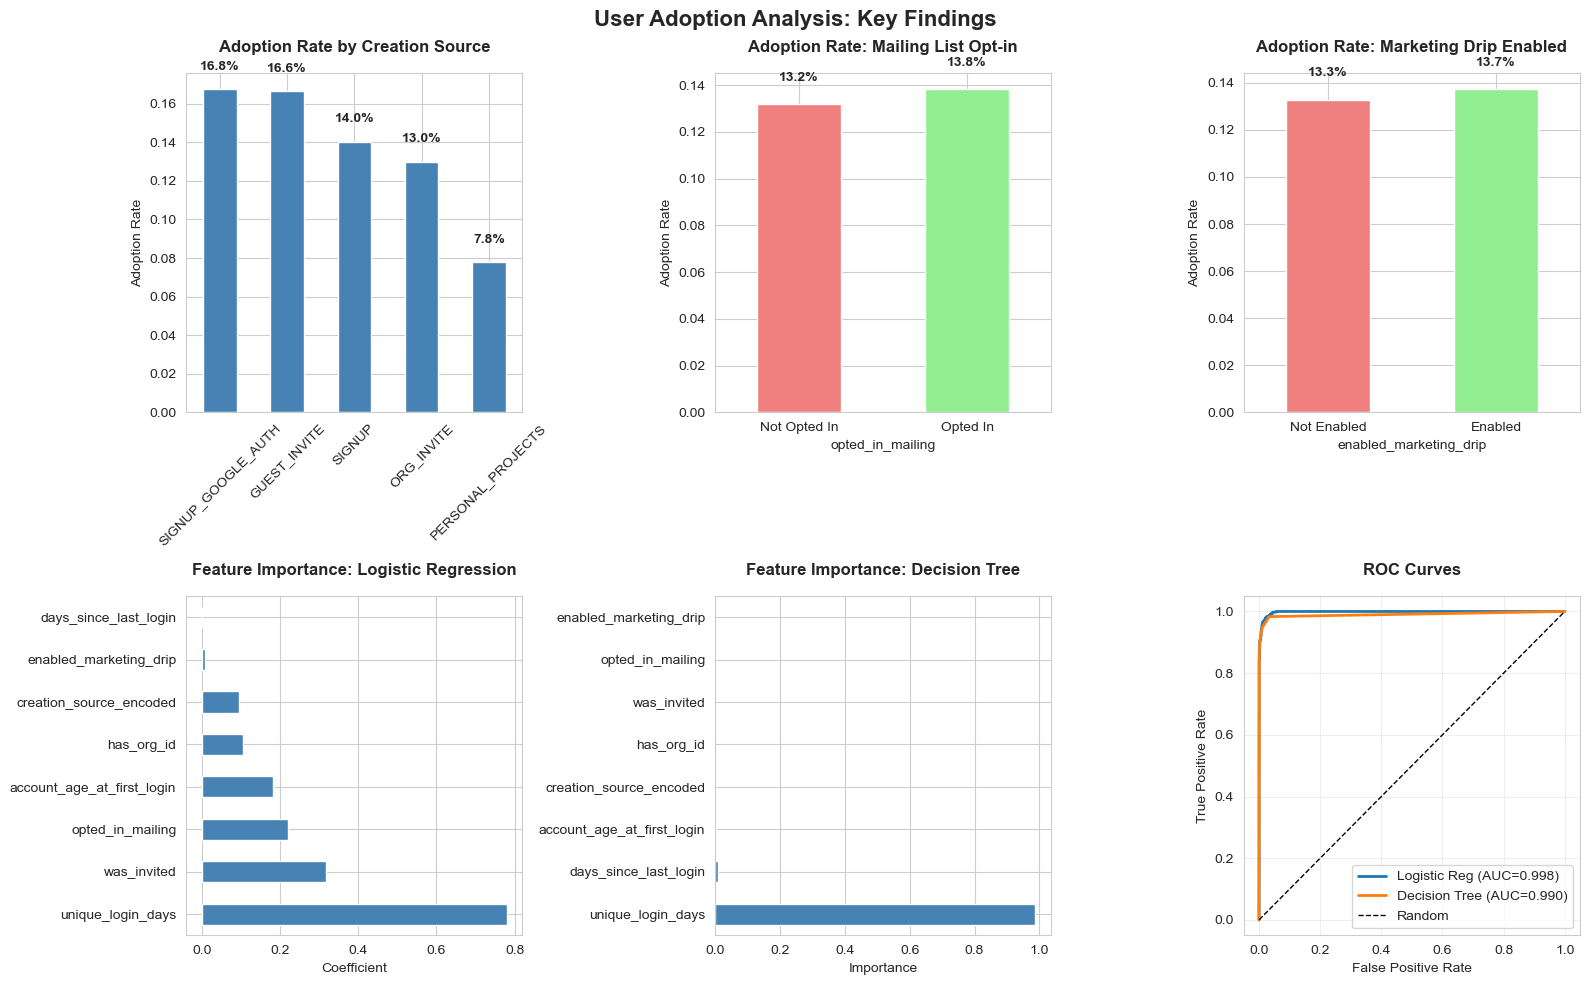

In [32]:
# Create a comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('User Adoption Analysis: Key Findings', fontsize=16, fontweight='bold')

# 1. Adoption Rate by Creation Source
ax = axes[0, 0]
adoption_source = features_df.groupby('creation_source')['is_adopted'].mean().sort_values(ascending=False)
adoption_source.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Adoption Rate by Creation Source', fontweight='bold', pad=15)
ax.set_ylabel('Adoption Rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(adoption_source.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 2. Impact of Mailing List Opt-in
ax = axes[0, 1]
mailing_adoption = features_df.groupby('opted_in_mailing')['is_adopted'].mean()
labels = ['Not Opted In', 'Opted In']
mailing_adoption.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_title('Adoption Rate: Mailing List Opt-in', fontweight='bold', pad=15)
ax.set_ylabel('Adoption Rate')
ax.set_xticklabels(labels, rotation=0)
for i, v in enumerate(mailing_adoption.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 3. Impact of Marketing Drip
ax = axes[0, 2]
drip_adoption = features_df.groupby('enabled_marketing_drip')['is_adopted'].mean()
labels = ['Not Enabled', 'Enabled']
drip_adoption.plot(kind='bar', ax=ax, color=['lightcoral', 'lightgreen'])
ax.set_title('Adoption Rate: Marketing Drip Enabled', fontweight='bold', pad=15)
ax.set_ylabel('Adoption Rate')
ax.set_xticklabels(labels, rotation=0)
for i, v in enumerate(drip_adoption.values):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')

# 4. Feature Importance - Logistic Regression
ax = axes[1, 0]
feature_importance_lr.plot(x='feature', y='coefficient', kind='barh', ax=ax, legend=False, color='steelblue')
ax.set_title('Feature Importance: Logistic Regression', fontweight='bold', pad=15)
ax.set_xlabel('Coefficient')
ax.set_ylabel('')

# 5. Feature Importance - Decision Tree
ax = axes[1, 1]
feature_importance_dt.plot(x='feature', y='importance', kind='barh', ax=ax, legend=False, color='steelblue')
ax.set_title('Feature Importance: Decision Tree', fontweight='bold', pad=15)
ax.set_xlabel('Importance')
ax.set_ylabel('')

# 6. ROC Curves
ax = axes[1, 2]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
ax.plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})', linewidth=2)
ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_title('ROC Curves', fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary of Findings

### Overall Adoption Metrics
- **Definition**: Users with 3+ logins within a 7-day period are considered adopted
- **Total Users**: 12,000
- **Adopted Users**: 1,602 (13.35% adoption rate)
- **Model Performance**: Logistic Regression achieves 99.84% ROC-AUC; Decision Tree achieves 99.00% ROC-AUC

### Key Adoption Drivers (Ranked by Impact)

1. **User Invitations** (Highest Impact)
   - Invited users: 14.23% adoption rate
   - Non-invited users: 12.34% adoption rate
   - **Uplift: 1.89 percentage points**

2. **Mailing List Opt-in**
   - Opted In: 13.83% adoption rate
   - Not Opted In: 13.19% adoption rate
   - **Uplift: 0.64 percentage points**

3. **Marketing Drip Campaigns**
   - Enabled: 13.73% adoption rate
   - Disabled: 13.28% adoption rate
   - **Uplift: 0.44 percentage points**

4. **Creation Source**
   - Top performer: SIGNUP_GOOGLE_AUTH (16.75% adoption rate)
   - Significantly outperforms other channels

5. **Organization Affiliation**
   - All users in dataset have organization IDs (13.35% adoption rate)
   - No comparative group available

### Model Performance
- **Logistic Regression**: 98.42% accuracy, 0.9984 ROC-AUC
- **Decision Tree**: 98.56% accuracy, 0.9900 ROC-AUC
- **Top Predictive Feature**: Unique login days (98.71% importance in Decision Tree)

### Strategic Recommendations
1. **High Priority**: Leverage user invitations—shows largest uplift of 1.89 percentage points
2. **Growth Strategy**: Focus on SIGNUP_GOOGLE_AUTH channel for new user acquisition
3. **Engagement**: Encourage mailing list opt-ins and marketing drip enrollment to drive adoption
4. **Retention**: Target non-logged-in users with re-engagement campaigns
5. **Model Application**: Deploy Logistic Regression model (slightly better ROC-AUC) for adoption prediction
